## **Import Library**

In [80]:
# Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from wordcloud import WordCloud
import csv
import requests
from io import StringIO
import pickle

# Import Library NLTK (Natural Language Toolkit)
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Import Library untuk pemrosesan bahasa Indonesia
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

# Import library untuk preprocessing
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.svm import SVC

# Import Library deep learning
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, GRU 
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

[nltk_data] Downloading package punkt to C:\Users\Aflah
[nltk_data]     Ghozi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\Aflah
[nltk_data]     Ghozi\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Aflah
[nltk_data]     Ghozi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## **Loading Dataset**

In [ ]:
df = pd.read_csv('ulasan_aplikasi.csv')
df.head()

,reviewId,content,score
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak. Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan.",1
3,8b12a49c-0320-49bd-8c1a-76ee0af51745,"Sistem yang aneh, kenapa? [1] Hanya bisa beli tiket berisi maksimal empat orang. Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket. [2] Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama (karena maks empat). Padahal saya sendiri yang daftarkan. [3] Tidak ada fitur perubahan data penumpang, misal ingin saya ganti dengan nama lain.",1
4,807a5913-129c-4484-8965-66a5314849c1,"Masukan untuk sistem pembayaran di opsi e-wallet, sebelumnya sudah menambahkan shopeepay tp ketika mau bayar dengan shopeepay selalu gak ada opsi nya, ketika klik tambah e-wallet baru muncul, ketika di klik tp hanya ada opsi hapus shopeepay",4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  55000 non-null  object
 1   content   55000 non-null  object
 2   score     55000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ MB


In [ ]:
df.isnull().sum()

reviewId    0
content     0
score       0
dtype: int64

In [ ]:
df.duplicated().sum()

np.int64(0)

In [85]:
# Menghapus data duplikat
df_cleaned = df.drop_duplicates()
# Menampilkan informasi data setelah dihapus
df_cleaned.info()
# Menampilkan 5 data teratas setelah dihapus
df_cleaned.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55000 entries, 0 to 54999
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   reviewId  55000 non-null  object
 1   content   55000 non-null  object
 2   score     55000 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 1.3+ MB


,reviewId,content,score
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak. Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan.",1
3,8b12a49c-0320-49bd-8c1a-76ee0af51745,"Sistem yang aneh, kenapa? [1] Hanya bisa beli tiket berisi maksimal empat orang. Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket. [2] Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama (karena maks empat). Padahal saya sendiri yang daftarkan. [3] Tidak ada fitur perubahan data penumpang, misal ingin saya ganti dengan nama lain.",1
4,807a5913-129c-4484-8965-66a5314849c1,"Masukan untuk sistem pembayaran di opsi e-wallet, sebelumnya sudah menambahkan shopeepay tp ketika mau bayar dengan shopeepay selalu gak ada opsi nya, ketika klik tambah e-wallet baru muncul, ketika di klik tp hanya ada opsi hapus shopeepay",4


## **Preprocessing Text**

### **Remove Special Characters**

In [86]:
def cleaningText(text):
    text = re.sub(r'@[A-Za-z0-9]+', '', text) # menghapus mention
    text = re.sub(r'#[A-Za-z0-9]+', '', text) # menghapus hashtag
    text = re.sub(r'RT[\s]', '', text) # menghapus RT
    text = re.sub(r"http\S+", '', text) # menghapus link
    text = re.sub(r'[0-9]+', '', text) # menghapus angka
    text = re.sub(r'[^\w\s]', '', text) # menghapus karakter selain huruf dan angka
 
    text = text.replace('\n', ' ') # mengganti baris baru dengan spasi
    text = text.translate(str.maketrans('', '', string.punctuation)) # menghapus semua tanda baca
    text = text.strip(' ') # menghapus karakter spasi dari kiri dan kanan teks
    return text

In [87]:
df_cleaned['text_clean'] = df_cleaned['content'].apply(cleaningText)
df_cleaned.head()

,reviewId,content,score,text_clean
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak. Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan.",1,Tolong aplikasinya diperbaiki mau pesan tiket tidak bisa loading terus sekalinya bisa tempat duduk sudah tidak tersedia Terus ketika pembayaran juga ada problem keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan
3,8b12a49c-0320-49bd-8c1a-76ee0af51745,"Sistem yang aneh, kenapa? [1] Hanya bisa beli tiket berisi maksimal empat orang. Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket. [2] Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama (karena maks empat). Padahal saya sendiri yang daftarkan. [3] Tidak ada fitur perubahan data penumpang, misal ingin saya ganti dengan nama lain.",1,Sistem yang aneh kenapa Hanya bisa beli tiket berisi maksimal empat orang Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama karena maks empat Padahal saya sendiri yang daftarkan Tidak ada fitur perubahan data penumpang misal ingin saya ganti dengan nama lain
4,807a5913-129c-4484-8965-66a5314849c1,"Masukan untuk sistem pembayaran di opsi e-wallet, sebelumnya sudah menambahkan shopeepay tp ketika mau bayar dengan shopeepay selalu gak ada opsi nya, ketika klik tambah e-wallet baru muncul, ketika di klik tp hanya ada opsi hapus shopeepay",4,Masukan untuk sistem pembayaran di opsi ewallet sebelumnya sudah menambahkan shopeepay tp ketika mau bayar dengan shopeepay selalu gak ada opsi nya ketika klik tambah ewallet baru muncul ketika di klik tp hanya ada opsi hapus shopeepay


### **Case Folding**

In [88]:
def casefoldingText(text): # Mengubah semua karakter dalam teks menjadi huruf kecil
    text = text.lower()
    return text

df_cleaned['text_casefoldingText'] = df_cleaned['text_clean'].apply(casefoldingText)
df_cleaned.head()

,reviewId,content,score,text_clean,text_casefoldingText
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak. Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan.",1,Tolong aplikasinya diperbaiki mau pesan tiket tidak bisa loading terus sekalinya bisa tempat duduk sudah tidak tersedia Terus ketika pembayaran juga ada problem keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan,tolong aplikasinya diperbaiki mau pesan tiket tidak bisa loading terus sekalinya bisa tempat duduk sudah tidak tersedia terus ketika pembayaran juga ada problem keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi jadi harus menghubingi cs dulu buat minta kode bookingnya biar bisa dicetak sudah berulang kali kayak gini tapi masih aja gk ada perbaikan
3,8b12a49c-0320-49bd-8c1a-76ee0af51745,"Sistem yang aneh, kenapa? [1] Hanya bisa beli tiket berisi maksimal empat orang. Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket. [2] Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama (karena maks empat). Padahal saya sendiri yang daftarkan. [3] Tidak ada fitur perubahan data penumpang, misal ingin saya ganti dengan nama lain.",1,Sistem yang aneh kenapa Hanya bisa beli tiket berisi maksimal empat orang Jadi ketika daftar suami istri dan tiga anak terpaksa salah satu tidak dalam satu tiket Tidak bisa membatalkan salah satu nama karena saya bukan salah satu dari list nama ka

### **Slang Words**

In [89]:
slangwords = {"bug":"masalah", "duit":"uang", "habi":"habis", "sya":"saya", "bagu":"bagus", "rb":"ribu", "kendala":"gangguan", "topup":"top up", "gabisa":"tidak bisa", "sdh":"sudah", "min":"admin", "ribet":"susah", "app":"aplikasi", "prose":"proses", "hp":"gawai", "eror":"error", "pa":"apa", "apk":"aplikasi", "gampang":"mudah", "aplikasinya":"aplikasi", "g":"tidak", "gk":"tidak", "tf":"transfer","parah":"buruk", "terimakasih":"terima kasih", "udh":"sudah", "@": "di", "abis": "habis", "wtb": "beli", "masi": "masih", "wts": "jual", "wtt": "tukar", "bgt": "banget", "maks": "maksimal", "plisss": "tolong", "bgttt": "banget", "indo": "indonesia", "bgtt": "banget", "ad": "ada", "rv": "redvelvet", "plis": "tolong", "pls": "tolong", "cr": "sumber", "cod": "bayar ditempat", "adlh": "adalah", "afaik": "as far as i know", "ahaha": "haha", "aj": "saja", "ajep-ajep": "dunia gemerlap", "ak": "saya", "akika": "aku", "akkoh": "aku", "akuwh": "aku", "alay": "norak", "alow": "halo", "ambilin": "ambilkan", "ancur": "hancur", "anjrit": "anjing", "anter": "antar", "ap2": "apa-apa", "apasih": "apa sih", "apes": "sial", "aps": "apa", "aq": "saya", "aquwh": "aku", "asbun": "asal bunyi", "aseekk": "asyik", "asekk": "asyik", "asem": "asam", "aspal": "asli tetapi palsu", "astul": "asal tulis", "ato": "atau", "au ah": "tidak mau tahu", "awak": "saya", "ay": "sayang", "ayank": "sayang", "b4": "sebelum", "bakalan": "akan", "bandes": "bantuan desa", "bangedh": "banget", "banpol": "bantuan polisi", "banpur": "bantuan tempur", "basbang": "basi", "bcanda": "bercanda", "bdg": "bandung", "begajulan": "nakal", "beliin": "belikan", "bencong": "banci", "bentar": "sebentar", "ber3": "bertiga", "beresin": "membereskan", "bete": "bosan", "beud": "banget", "bg": "abang", "bgmn": "bagaimana", "bgt": "banget", "bijimane": "bagaimana", "bintal": "bimbingan mental", "bkl": "akan", "bknnya": "bukannya", "blegug": "bodoh", "blh": "boleh", "bln": "bulan", "blum": "belum", "bnci": "benci", "bnran": "yang benar", "bodor": "lucu", "bokap": "ayah", "boker": "buang air besar", "bokis": "bohong", "boljug": "boleh juga", "bonek": "bocah nekat", "boyeh": "boleh", "br": "baru", "brg": "bareng", "bro": "saudara laki-laki", "bru": "baru", "bs": "bisa", "bsen": "bosan", "bt": "buat", "btw": "ngomong-ngomong", "buaya": "tidak setia", "bubbu": "tidur", "bubu": "tidur", "bumil": "ibu hamil", "bw": "bawa", "bwt": "buat", "byk": "banyak", "byrin": "bayarkan", "cabal": "sabar", "cadas": "keren", "calo": "makelar", "can": "belum", "capcus": "pergi", "caper": "cari perhatian", "ce": "cewek", "cekal": "cegah tangkal", "cemen": "penakut", "cengengesan": "tertawa", "cepet": "cepat", "cew": "cewek", "chuyunk": "sayang", "cimeng": "ganja", "cipika cipiki": "cium pipi kanan cium pipi kiri", "ciyh": "sih", "ckepp": "cakep", "ckp": "cakep", "cmiiw": "correct me if i'm wrong", "cmpur": "campur", "cong": "banci", "conlok": "cinta lokasi", "cowwyy": "maaf", "cp": "siapa", "cpe": "capek", "cppe": "capek", "cucok": "cocok", "cuex": "cuek", "cumi": "Cuma miscall", "cups": "culun", "curanmor": "pencurian kendaraan bermotor", "curcol": "curahan hati colongan", "cwek": "cewek", "cyin": "cinta", "d": "di", "dah": "deh", "dapet": "dapat", "de": "adik", "dek": "adik", "demen": "suka", "deyh": "deh", "dgn": "dengan", "diancurin": "dihancurkan", "dimaafin": "dimaafkan", "dimintak": "diminta", "disono": "di sana", "dket": "dekat", "dkk": "dan kawan-kawan", "dll": "dan lain-lain", "dlu": "dulu", "dngn": "dengan", "dodol": "bodoh", "doku": "uang", "dongs": "dong", "dpt": "dapat", "dri": "dari", "drmn": "darimana", "drtd": "dari tadi", "dst": "dan seterusnya", "dtg": "datang", "duh": "aduh", "duren": "durian", "ed": "edisi", "egp": "emang gue pikirin", "eke": "aku", "elu": "kamu", "emangnya": "memangnya", "emng": "memang", "endak": "tidak", "enggak": "tidak", "envy": "iri", "ex": "mantan", "fax": "facsimile", "fifo": "first in first out", "folbek": "follow back", "fyi": "sebagai informasi", "gaada": "tidak ada uang", "gag": "tidak", "gaje": "tidak jelas", "gak papa": "tidak apa-apa", "gan": "juragan", "gaptek": "gagap teknologi", "gatek": "gagap teknologi", "gawe": "kerja", "gbs": "tidak bisa", "gebetan": "orang yang disuka", "geje": "tidak jelas", "gepeng": "gelandangan dan pengemis", "ghiy": "lagi", "gile": "gila", "gimana": "bagaimana", "gino": "gigi nongol", "githu": "gitu", "gj": "tidak jelas", "gmana": "bagaimana", "gn": "begini", "goblok": "bodoh", "golput": "golongan putih", "gowes": "mengayuh sepeda", "gpny": "tidak punya", "gr": "gede rasa", "gretongan": "gratisan", "gtau": "tidak tahu", "gua": "saya", "guoblok": "goblok", "gw": "saya", "ha": "tertawa", "haha": "tertawa", "hallow": "halo", "hankam": "pertahanan dan keamanan", "hehe": "he", "helo": "halo", "hey": "hai", "hlm": "halaman", "hny": "hanya", "hoax": "isu bohong", "hr": "hari", "hrus": "harus", "hubdar": "perhubungan darat", "huff": "mengeluh", "hum": "rumah", "humz": "rumah", "ilang": "hilang", "ilfil": "tidak suka", "imho": "in my humble opinion", "imoetz": "imut", "item": "hitam", "itungan": "hitungan", "iye": "iya", "ja": "saja", "jadiin": "jadi", "jaim": "jaga image", "jayus": "tidak lucu", "jdi": "jadi", "jem": "jam", "jga": "juga", "jgnkan": "jangankan", "jir": "anjing", "jln": "jalan", "jomblo": "tidak punya pacar", "jubir": "juru bicara", "jutek": "galak", "k": "ke", "kab": "kabupaten", "kabor": "kabur", "kacrut": "kacau", "kadiv": "kepala divisi", "kagak": "tidak", "kalo": "kalau", "kampret": "sialan", "kamtibmas": "keamanan dan ketertiban masyarakat", "kamuwh": "kamu", "kanwil": "kantor wilayah", "karna": "karena", "kasubbag": "kepala subbagian", "katrok": "kampungan", "kayanya": "kayaknya", "kbr": "kabar", "kdu": "harus", "kec": "kecamatan", "kejurnas": "kejuaraan nasional", "kekeuh": "keras kepala", "kel": "kelurahan", "kemaren": "kemarin", "kepengen": "mau", "kepingin": "mau", "kepsek": "kepala sekolah", "kesbang": "kesatuan bangsa", "kesra": "kesejahteraan rakyat", "ketrima": "diterima", "kgiatan": "kegiatan", "kibul": "bohong", "kimpoi": "kawin", "kl": "kalau", "klianz": "kalian", "kloter": "kelompok terbang", "klw": "kalau", "km": "kamu", "kmps": "kampus", "kmrn": "kemarin", "knal": "kenal", "knp": "kenapa", "kodya": "kota madya", "komdis": "komisi disiplin", "komsov": "komunis sovyet", "kongkow": "kumpul bareng teman-teman", "kopdar": "kopi darat", "korup": "korupsi", "kpn": "kapan", "krenz": "keren", "krm": "kirim", "kt": "kita", "ktmu": "ketemu", "ktr": "kantor", "kuper": "kurang pergaulan", "kw": "imitasi", "kyk": "seperti", "la": "lah", "lam": "salam", "lamp": "lampiran", "lanud": "landasan udara", "latgab": "latihan gabungan", "lebay": "berlebihan", "leh": "boleh", "lelet": "lambat", "lemot": "lambat", "lgi": "lagi", "lgsg": "langsung", "liat": "lihat", "litbang": "penelitian dan pengembangan", "lmyn": "lumayan", "lo": "kamu", "loe": "kamu", "lola": "lambat berfikir", "louph": "cinta", "low": "kalau", "lp": "lupa", "luber": "langsung, umum, bebas, dan rahasia", "luchuw": "lucu", "lum": "belum", "luthu": "lucu", "lwn": "lawan", "maacih": "terima kasih", "mabal": "bolos", "macem": "macam", "macih": "masih", "maem": "makan", "magabut": "makan gaji buta", "maho": "homo", "mak jang": "kaget", "maksain": "memaksa", "malem": "malam", "mam": "makan", "maneh": "kamu", "maniez": "manis", "mao": "mau", "masukin": "masukkan", "melu": "ikut", "mepet": "dekat sekali", "mgu": "minggu", "migas": "minyak dan gas bumi", "mikol": "minuman beralkohol", "miras": "minuman keras", "mlah": "malah", "mngkn": "mungkin", "mo": "mau", "mokad": "mati", "moso": "masa", "mpe": "sampai", "msk": "masuk", "mslh": "masalah", "mt": "makan teman", "mubes": "musyawarah besar", "mulu": "melulu", "mumpung": "selagi", "munas": "musyawarah nasional", "muntaber": "muntah dan berak", "musti": "mesti", "muupz": "maaf", "mw": "now watching", "n": "dan", "nanam": "menanam", "nanya": "bertanya", "napa": "kenapa", "napi": "narapidana", "napza": "narkotika, alkohol, psikotropika, dan zat adiktif ", "narkoba": "narkotika, psikotropika, dan obat terlarang", "nasgor": "nasi goreng", "nda": "tidak", "ndiri": "sendiri", "ne": "ini", "nekolin": "neokolonialisme", "nembak": "menyatakan cinta", "ngabuburit": "menunggu berbuka puasa", "ngaku": "mengaku", "ngambil": "mengambil", "nganggur": "tidak punya pekerjaan", "ngapah": "kenapa", "ngaret": "terlambat", "ngasih": "memberikan", "ngebandel": "berbuat bandel", "ngegosip": "bergosip", "ngeklaim": "mengklaim", "ngeksis": "menjadi eksis", "ngeles": "berkilah", "ngelidur": "menggigau", "ngerampok": "merampok", "ngga": "tidak", "ngibul": "berbohong", "ngiler": "mau", "ngiri": "iri", "ngisiin": "mengisikan", "ngmng": "bicara", "ngomong": "bicara", "ngubek2": "mencari-cari", "ngurus": "mengurus", "nie": "ini", "nih": "ini", "niyh": "nih", "nmr": "nomor", "nntn": "nonton", "nobar": "nonton bareng", "np": "now playing", "ntar": "nanti", "ntn": "nonton", "numpuk": "bertumpuk", "nutupin": "menutupi", "nyari": "mencari", "nyekar": "menyekar", "nyicil": "mencicil", "nyoblos": "mencoblos", "nyokap": "ibu", "ogah": "tidak mau", "ol": "online", "ongkir": "ongkos kirim", "oot": "out of topic", "org2": "orang-orang", "ortu": "orang tua", "otda": "otonomi daerah", "otw": "on the way, sedang di jalan", "pacal": "pacar", "pake": "pakai", "pala": "kepala", "pansus": "panitia khusus", "parpol": "partai politik", "pasutri": "pasangan suami istri", "pd": "pada", "pede": "percaya diri", "pelatnas": "pemusatan latihan nasional", "pemda": "pemerintah daerah", "pemkot": "pemerintah kota", "pemred": "pemimpin redaksi", "penjas": "pendidikan jasmani", "perda": "peraturan daerah", "perhatiin": "perhatikan", "pesenan": "pesanan", "pgang": "pegang", "pi": "tapi", "pilkada": "pemilihan kepala daerah", "pisan": "sangat", "pk": "penjahat kelamin", "plg": "paling", "pmrnth": "pemerintah", "polantas": "polisi lalu lintas", "ponpes": "pondok pesantren", "pp": "pulang pergi", "prg": "pergi", "prnh": "pernah", "psen": "pesan", "pst": "pasti", "pswt": "pesawat", "pw": "posisi nyaman", "qmu": "kamu", "rakor": "rapat koordinasi", "ranmor": "kendaraan bermotor", "re": "reply", "ref": "referensi", "rehab": "rehabilitasi", "rempong": "sulit", "repp": "balas", "restik": "reserse narkotika", "rhs": "rahasia", "rmh": "rumah", "ru": "baru", "ruko": "rumah toko", "rusunawa": "rumah susun sewa", "ruz": "terus", "saia": "saya", "salting": "salah tingkah", "sampe": "sampai", "samsek": "sama sekali", "sapose": "siapa", "satpam": "satuan pengamanan", "sbb": "sebagai berikut", "sbh": "sebuah", "sbnrny": "sebenarnya", "scr": "secara", "sdgkn": "sedangkan", "sdkt": "sedikit", "se7": "setuju", "sebelas dua belas": "mirip", "sembako": "sembilan bahan pokok", "sempet": "sempat", "sendratari": "seni drama tari", "sgt": "sangat", "shg": "sehingga", "siech": "sih", "sikon": "situasi dan kondisi", "sinetron": "sinema elektronik", "siramin": "siramkan", "sj": "saja", "skalian": "sekalian", "sklh": "sekolah", "skt": "sakit", "slesai": "selesai", "sll": "selalu", "slma": "selama", "slsai": "selesai", "smpt": "sempat", "smw": "semua", "sndiri": "sendiri", "soljum": "sholat jumat", "songong": "sombong", "sory": "maaf", "sosek": "sosial-ekonomi", "sotoy": "sok tahu", "spa": "siapa", "sppa": "siapa", "spt": "seperti", "srtfkt": "sertifikat", "stiap": "setiap", "stlh": "setelah", "suk": "masuk", "sumpek": "sempit", "syg": "sayang", "t4": "tempat", "tajir": "kaya", "tau": "tahu", "taw": "tahu", "td": "tadi", "tdk": "tidak", "teh": "kakak perempuan", "telat": "terlambat", "telmi": "telat berpikir", "temen": "teman", "tengil": "menyebalkan", "tepar": "terkapar", "tggu": "tunggu", "tgu": "tunggu", "thankz": "terima kasih", "thn": "tahun", "tilang": "bukti pelanggaran", "tipiwan": "TvOne", "tks": "terima kasih", "tlp": "telepon", "tls": "tulis", "tmbah": "tambah", "tmen2": "teman-teman", "tmpah": "tumpah", "tmpt": "tempat", "tngu": "tunggu", "tnyta": "ternyata", "tokai": "tai", "toserba": "toko serba ada", "tpi": "tapi", "trdhulu": "terdahulu", "trima": "terima kasih", "trm": "terima", "trs": "terus", "trutama": "terutama", "ts": "penulis", "tst": "tahu sama tahu", "ttg": "tentang", "tuch": "tuh", "tuir": "tua", "tw": "tahu", "u": "kamu", "ud": "sudah", "udah": "sudah", "ujg": "ujung", "ul": "ulangan", "unyu": "lucu", "uplot": "unggah", "urang": "saya", "usah": "perlu", "utk": "untuk", "valas": "valuta asing", "w/": "dengan", "wadir": "wakil direktur", "wamil": "wajib militer", "warkop": "warung kopi", "warteg": "warung tegal", "wat": "buat", "wkt": "waktu", "wtf": "what the fuck", "xixixi": "tertawa", "ya": "iya", "yap": "iya", "yaudah": "ya sudah", "yawdah": "ya sudah", "yg": "yang", "yl": "yang lain", "yo": "iya", "yowes": "ya sudah", "yup": "iya", "7an": "tujuan", "ababil": "abg labil", "acc": "accord", "adlah": "adalah", "adoh": "aduh", "aha": "tertawa", "aing": "saya", "aja": "saja", "ajj": "saja", "aka": "dikenal juga sebagai", "akko": "aku", "akku": "aku", "akyu": "aku", "aljasa": "asal jadi saja", "ama": "sama", "ambl": "ambil", "anjir": "anjing", "ank": "anak", "ap": "apa", "apaan": "apa", "ape": "apa", "aplot": "unggah", "apva": "apa", "aqu": "aku", "asap": "sesegera mungkin", "aseek": "asyik", "asek": "asyik", "aseknya": "asyiknya", "asoy": "asyik", "astrojim": "astagfirullahaladzim", "ath": "kalau begitu", "atuh": "kalau begitu", "ava": "avatar", "aws": "awas", "ayang": "sayang", "ayok": "ayo", "bacot": "banyak bicara", "bales": "balas", "bangdes": "pembangunan desa", "bangkotan": "tua", "banpres": "bantuan presiden", "bansarkas": "bantuan sarana kesehatan", "bazis": "badan amal, zakat, infak, dan sedekah", "bcoz": "karena", "beb": "sayang", "bejibun": "banyak", "belom": "belum", "bener": "benar", "ber2": "berdua", "berdikari": "berdiri di atas kaki sendiri", "bet": "banget", "beti": "beda tipis", "beut": "banget", "bgd": "banget", "bgs": "bagus", "bhubu": "tidur", "bimbuluh": "bimbingan dan penyuluhan", "bisi": "kalau-kalau", "bkn": "bukan", "bl": "beli", "blg": "bilang", "blm": "belum", "bls": "balas", "bnchi": "benci", "bngung": "bingung", "bnyk": "banyak", "bohay": "badan aduhai", "bokep": "porno", "bokin": "pacar", "bole": "boleh", "bolot": "bodoh", "bonyok": "ayah ibu", "bpk": "bapak", "brb": "segera kembali", "brngkt": "berangkat", "brp": "berapa", "brur": "saudara laki-laki", "bsa": "bisa", "bsk": "besok", "bu_bu": "tidur", "bubarin": "bubarkan", "buber": "buka bersama", "bujubune": "luar biasa", "buser": "buru sergap", "bwhn": "bawahan", "byar": "bayar", "byr": "bayar", "c8": "chat", "cabut": "pergi", "caem": "cakep", "cama-cama": "sama-sama", "cangcut": "celana dalam", "cape": "capek", "caur": "jelek", "cekak": "tidak ada uang", "cekidot": "coba lihat", "cemplungin": "cemplungkan", "ceper": "pendek", "ceu": "kakak perempuan", "cewe": "cewek", "cibuk": "sibuk", "cin": "cinta", "ciye": "cie", "ckck": "ck", "clbk": "cinta lama bersemi kembali", "cmpr": "campur", "cnenk": "senang", "congor": "mulut", "cow": "cowok", "coz": "karena", "cpa": "siapa", "gokil": "gila", "gombal": "suka merayu", "gpl": "tidak pakai lama", "gpp": "tidak apa-apa", "gretong": "gratis", "gt": "begitu", "gtw": "tidak tahu", "gue": "saya", "guys": "teman-teman", "gws": "cepat sembuh", "haghaghag": "tertawa", "hakhak": "tertawa", "handak": "bahan peledak", "hansip": "pertahanan sipil", "hellow": "halo", "helow": "halo", "hi": "hai", "hlng": "hilang", "hnya": "hanya", "houm": "rumah", "hrs": "harus", "hubad": "hubungan angkatan darat", "hubla": "perhubungan laut", "huft": "mengeluh", "humas": "hubungan masyarakat", "idk": "saya tidak tahu", "ilfeel": "tidak suka", "imba": "jago sekali", "imoet": "imut", "info": "informasi", "itung": "hitung", "isengin": "bercanda", "iyala": "iya lah", "iyo": "iya", "jablay": "jarang dibelai", "jadul": "jaman dulu", "jancuk": "anjing", "jd": "jadi", "jdikan": "jadikan", "jg": "juga", "jgn": "jangan", "jijay": "jijik", "jkt": "jakarta", "jnj": "janji", "jth": "jatuh", "jurdil": "jujur adil", "jwb": "jawab", "ka": "kakak", "kabag": "kepala bagian", "kacian": "kasihan", "kadit": "kepala direktorat", "kaga": "tidak", "kaka": "kakak", "kamtib": "keamanan dan ketertiban", "kamuh": "kamu", "kamyu": "kamu", "kapt": "kapten", "kasat": "kepala satuan", "kasubbid": "kepala subbidang", "kau": "kamu", "kbar": "kabar", "kcian": "kasihan", "keburu": "terlanjur", "kedubes": "kedutaan besar", "kek": "seperti", "keknya": "kayaknya", "keliatan": "kelihatan", "keneh": "masih", "kepikiran": "terpikirkan", "kepo": "mau tahu urusan orang", "kere": "tidak punya uang", "kesian": "kasihan", "ketauan": "ketahuan", "keukeuh": "keras kepala", "khan": "kan", "kibus": "kaki busuk", "kk": "kakak", "klian": "kalian", "klo": "kalau", "kluarga": "keluarga", "klwrga": "keluarga", "kmari": "kemari", "kmpus": "kampus", "kn": "kan", "knl": "kenal", "knpa": "kenapa", "kog": "kok", "kompi": "komputer", "komtiong": "komunis Tiongkok", "konjen": "konsulat jenderal", "koq": "kok", "kpd": "kepada", "kptsan": "keputusan", "krik": "garing", "krn": "karena", "ktauan": "ketahuan", "ktny": "katanya", "kudu": "harus", "kuq": "kok", "ky": "seperti", "kykny": "kayanya", "laka": "kecelakaan", "lambreta": "lambat", "lansia": "lanjut usia", "lapas": "lembaga pemasyarakatan", "lbur": "libur", "lekong": "laki-laki", "lg": "lagi", "lgkp": "lengkap", "lht": "lihat", "linmas": "perlindungan masyarakat", "lmyan": "lumayan", "lngkp": "lengkap", "loch": "loh", "lol": "tertawa", "lom": "belum", "loupz": "cinta", "lowh": "kamu", "lu": "kamu", "luchu": "lucu", "luff": "cinta", "luph": "cinta", "lw": "kamu", "lwt": "lewat", "maaciw": "terima kasih", "mabes": "markas besar", "macem-macem": "macam-macam", "madesu": "masa depan suram", "maen": "main", "mahatma": "maju sehat bersama", "mak": "ibu", "makasih": "terima kasih", "malah": "bahkan", "malu2in": "memalukan", "mamz": "makan", "manies": "manis", "mantep": "mantap", "markus": "makelar kasus", "mba": "mbak", "mending": "lebih baik", "mgkn": "mungkin", "mhn": "mohon", "miker": "minuman keras", "milis": "mailing list", "mksd": "maksud", "mls": "malas", "mnt": "minta", "moge": "motor gede", "mokat": "mati", "mosok": "masa", "msh": "masih", "mskpn": "meskipun", "msng2": "masing-masing", "muahal": "mahal", "muker": "musyawarah kerja", "mumet": "pusing", "muna": "munafik", "munaslub": "musyawarah nasional luar biasa", "musda": "musyawarah daerah", "muup": "maaf", "muuv": "maaf", "nal": "kenal", "nangis": "menangis", "naon": "apa", "napol": "narapidana politik", "naq": "anak", "narsis": "bangga pada diri sendiri", "nax": "anak", "ndak": "tidak", "ndut": "gendut", "nekolim": "neokolonialisme", "nelfon": "menelepon", "ngabis2in": "menghabiskan", "ngakak": "tertawa", "ngambek": "marah", "ngampus": "pergi ke kampus", "ngantri": "mengantri", "ngapain": "sedang apa", "ngaruh": "berpengaruh", "ngawur": "berbicara sembarangan", "ngeceng": "kumpul bareng-bareng", "ngeh": "sadar", "ngekos": "tinggal di kos", "ngelamar": "melamar", "ngeliat": "melihat", "ngemeng": "bicara terus-terusan", "ngerti": "mengerti", "nggak": "tidak", "ngikut": "ikut", "nginep": "menginap", "ngisi": "mengisi", "ngmg": "bicara", "ngocol": "lucu", "ngomongin": "membicarakan", "ngumpul": "berkumpul", "ni": "ini", "nyasar": "tersesat", "nyariin": "mencari", "nyiapin": "mempersiapkan", "nyiram": "menyiram", "nyok": "ayo", "o/": "oleh", "ok": "ok", "priksa": "periksa", "pro": "profesional", "psn": "pesan", "psti": "pasti", "puanas": "panas", "qmo": "kamu", "qt": "kita", "rame": "ramai", "raskin": "rakyat miskin", "red": "redaksi", "reg": "register", "rejeki": "rezeki", "renstra": "rencana strategis", "reskrim": "reserse kriminal", "sni": "sini", "somse": "sombong sekali", "sorry": "maaf", "sosbud": "sosial-budaya", "sospol": "sosial-politik", "sowry": "maaf", "spd": "sepeda", "sprti": "seperti", "spy": "supaya", "stelah": "setelah", "subbag": "subbagian", "sumbangin": "sumbangkan", "sy": "saya", "syp": "siapa", "tabanas": "tabungan pembangunan nasional", "tar": "nanti", "taun": "tahun", "tawh": "tahu", "tdi": "tadi", "te2p": "tetap", "tekor": "rugi", "telkom": "telekomunikasi", "telp": "telepon", "temen2": "teman-teman", "tengok": "menjenguk", "terbitin": "terbitkan", "tgl": "tanggal", "thanks": "terima kasih", "thd": "terhadap", "thx": "terima kasih", "tipi": "TV", "tkg": "tukang", "tll": "terlalu", "tlpn": "telepon", "tman": "teman", "tmbh": "tambah", "tmn2": "teman-teman", "tmph": "tumpah", "tnda": "tanda", "tnh": "tanah", "togel": "toto gelap", "tp": "tapi", "tq": "terima kasih", "trgntg": "tergantung", "trims": "terima kasih", "cb": "coba", "y": "ya", "munfik": "munafik", "reklamuk": "reklamasi", "sma": "sama", "tren": "trend", "ngehe": "kesal", "mz": "mas", "analisise": "analisis", "sadaar": "sadar", "sept": "september", "nmenarik": "menarik", "zonk": "bodoh", "rights": "benar", "simiskin": "miskin", "ngumpet": "sembunyi", "hardcore": "keras", "akhirx": "akhirnya", "solve": "solusi", "watuk": "batuk", "ngebully": "intimidasi", "masy": "masyarakat", "still": "masih", "tauk": "tahu", "mbual": "bual", "tioghoa": "tionghoa", "ngentotin": "senggama", "kentot": "senggama", "faktakta": "fakta", "sohib": "teman", "rubahnn": "rubah", "trlalu": "terlalu", "nyela": "cela", "heters": "pembenci", "nyembah": "sembah", "most": "paling", "ikon": "lambang", "light": "terang", "pndukung": "pendukung", "setting": "atur", "seting": "akting", "next": "lanjut", "waspadalah": "waspada", "gantengsaya": "ganteng", "parte": "partai", "nyerang": "serang", "nipu": "tipu", "ktipu": "tipu", "jentelmen": "berani", "buangbuang": "buang", "tsangka": "tersangka", "kurng": "kurang", "ista": "nista", "less": "kurang", "koar": "teriak", "paranoid": "takut", "problem": "masalah", "tahi": "kotoran", "tirani": "tiran", "tilep": "tilap", "happy": "bahagia", "tak": "tidak", "penertiban": "tertib", "uasai": "kuasa", "mnolak": "tolak", "trending": "trend", "taik": "tahi", "wkwkkw": "tertawa", "ahokncc": "ahok", "istaa": "nista", "benarjujur": "jujur", "mgkin": "mungkin"}
def fix_slangwords(text):
    words = text.split()
    fixed_words = []
 
    for word in words:
        if word.lower() in slangwords:
            fixed_words.append(slangwords[word.lower()])
        else:
            fixed_words.append(word)
 
    fixed_text = ' '.join(fixed_words)
    return fixed_text

# Mengganti kata-kata slang dengan kata-kata standar dan menyimpannya di 'text_slangwords'
df_cleaned['text_slangwords'] = df_cleaned['text_casefoldingText'].apply(fix_slangwords)
df_cleaned.head()

,reviewId,content,score,text_clean,text_casefoldingText,text_slangwords
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini aplikasi sudah cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak masalah eboarding pass tibatiba tidak bisa dibuka pas mau di scan end nya harus cetak ripuh benar heran etiket buat krl juga susah benar dibukanya load lama masalah sudah beli tiket krl tapi bahkan ga muncul pas mau dipake menyusahkan kecewa berat sudah berapa ribu uang hilang demi ini aplikasi stres
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak. Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan.",1,Tolong aplikasinya diperbaiki mau pesan tiket tidak bisa loading terus sekalinya bisa tempat duduk sudah tidak tersedia Terus ketika pembayaran juga ada problem keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi jadi harus menghubingi CS dulu buat minta kode bookingnya biar bisa dicetak Sudah berulang kali kayak gini tapi masih aja gk ada perbaikan,tolong aplikasinya diperbaiki mau pesan tiket tidak bisa loading terus sekalinya bisa tempat duduk sudah tidak tersedia terus ketika pembayaran juga ada problem keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi jadi harus menghubingi cs dulu buat minta kode bookingnya biar bisa dicetak sudah berulang kali kayak gini tapi masih aja gk 

### **Tokenizing**

In [90]:
def tokenizingText(text): # Memecah atau membagi string, teks menjadi daftar token
    text = word_tokenize(text)
    return text

# Memecah teks menjadi token (kata-kata) dan menyimpannya di 'text_tokenizingText'
df_cleaned['text_tokenizingText'] = df_cleaned['text_slangwords'].apply(tokenizingText)
df_cleaned.head()

,reviewId,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,"[sangat, bagus, dan, memudahkan, dalam, pemesanan, tiket, tanpa, perlu, antri, ke, loket, tapi, saat, ini, saya, ingin, melakukan, cetak, e, boarding, pas, tidak, bisa, buka, aplikasi, padahal, saat, ini, saya, sedang, ada, dalam, perjalanan, tolong, lekas, di, perbaiki, agar, saya, dapat, melakukan, cetak, e, boarding, pas]"
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini aplikasi sudah cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak masalah eboarding pass tibatiba tidak bisa dibuka pas mau di scan end nya harus cetak ripuh benar heran etiket buat krl juga susah benar dibukanya load lama masalah sudah beli tiket krl tapi bahkan ga muncul pas mau dipake menyusahkan kecewa berat sudah berapa ribu uang hilang demi ini aplikasi stres,"[sebenernya, ini, aplikasi, sudah, cukup, membantu, tapi, masih, banyak, yang, perlu, dinotis, sama, develop, masih, banyak, masalah, eboarding, pass, tibatiba, tidak, bisa, dibuka, pas, mau, di, scan, end, nya, harus, cetak, ripuh, benar, heran, etiket, buat, krl, juga, susah, benar, dibukanya, load, lama, masalah, sudah, beli, tiket, krl, tapi, bahkan, ga, muncul, pas, mau, dipake, menyusahkan, kecewa, berat, sudah, berapa, ribu, uang, hilang, demi, ini, aplikasi, stres]"
2,c11d6996-23cb-42b8-b0f8-31f5dcb5ac21,"Tolong aplikasinya diperbaiki, mau pesan tiket tidak bisa loading terus, sekalinya bisa tempat duduk sudah tidak tersedia. Terus ketika pembayaran juga ada problem, keterangan sudah berhasil dibayarkan tapi tiketnya tidak muncul diaplikasi, jadi harus menghubingi CS dulu buat minta kode book

### **Stopword Removal (Filtering)**

In [91]:
def filteringText(text): # Menghapus stopwords dalam teks
    listStopwords = set(stopwords.words('indonesian'))
    listStopwords1 = set(stopwords.words('english'))
    listStopwords.update(listStopwords1)
    listStopwords.update(['gini', 'oke', 'ok', 'log', 'ko', 'eh', 'cuman', 'doang', 'pas', 'orang', 'x', 'c', 'deh', 'biar', 'bikin', 'mohon', 'banget', 'kali', 'trus', 'gitu','iya','yaa','gak','nya','na','sih','ku',"di","ga","ya","gaa","loh","kah","woi","woii","woy"])
    filtered = []
    for txt in text:
        if txt not in listStopwords:
            filtered.append(txt)
    text = filtered
    return text

# Menghapus kata-kata stop (kata-kata umum) dan menyimpannya di 'text_stopword'
df_cleaned['text_stopword'] = df_cleaned['text_tokenizingText'].apply(filteringText)
df_cleaned.head()


,reviewId,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,"[sangat, bagus, dan, memudahkan, dalam, pemesanan, tiket, tanpa, perlu, antri, ke, loket, tapi, saat, ini, saya, ingin, melakukan, cetak, e, boarding, pas, tidak, bisa, buka, aplikasi, padahal, saat, ini, saya, sedang, ada, dalam, perjalanan, tolong, lekas, di, perbaiki, agar, saya, dapat, melakukan, cetak, e, boarding, pas]","[bagus, memudahkan, pemesanan, tiket, antri, loket, cetak, e, boarding, buka, aplikasi, perjalanan, tolong, lekas, perbaiki, cetak, e, boarding]"
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini aplikasi sudah cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak masalah eboarding pass tibatiba tidak bisa dibuka pas mau di scan end nya harus cetak ripuh benar heran etiket buat krl juga susah benar dibukanya load lama masalah sudah beli tiket krl tapi bahkan ga muncul pas mau dipake menyusahkan kecewa berat sudah berapa ribu uang hilang demi ini aplikasi stres,"[sebenernya, ini, aplikasi, sudah, cukup, membantu, tapi, masih, banyak, yang, perlu, dinotis, sama, develop, masih, banyak, masalah, eboarding, pass, tibatiba, tidak, bisa, dibuka, pas, mau, di, scan, end, nya, harus, cetak, ripuh, benar, heran, etiket, buat, krl, juga, susah, benar, dibukanya, load, lama, masalah, sudah, beli, tiket, krl, tapi, bahkan, ga, muncul, pas, mau, dipake, menyusahkan, kecewa, berat, sudah, berapa, ribu, uang, hilang, demi, ini, aplikasi, stres]","[sebenernya, aplikasi, membantu, dinotis, develop, eboarding, pass, tibatiba, dibuka, scan, end, cetak, ripuh, heran, etiket, krl, susah, dibukanya, load, beli, tiket, kr

### **Stemming**

In [92]:
def stemmingText(text): # Mengurangi kata ke bentuk dasarnya yang menghilangkan imbuhan awalan dan akhiran atau ke akar kata
    # Membuat objek stemmer
    factory = StemmerFactory()
    stemmer = factory.create_stemmer()
 
    # Memecah teks menjadi daftar kata
    words = text.split()
 
    # Menerapkan stemming pada setiap kata dalam daftar
    stemmed_words = [stemmer.stem(word) for word in words]
 
    # Menggabungkan kata-kata yang telah distem
    stemmed_text = ' '.join(stemmed_words)
 
    return stemmed_text

def toSentence(list_words): # Mengubah daftar kata menjadi kalimat
    sentence = ' '.join(word for word in list_words)
    return sentence

# Menggabungkan token-token menjadi kalimat dan menyimpannya di 'text_akhir'
df_cleaned['text_akhir'] = df_cleaned['text_stopword'].apply(toSentence)
df_cleaned.head()


,reviewId,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,"[sangat, bagus, dan, memudahkan, dalam, pemesanan, tiket, tanpa, perlu, antri, ke, loket, tapi, saat, ini, saya, ingin, melakukan, cetak, e, boarding, pas, tidak, bisa, buka, aplikasi, padahal, saat, ini, saya, sedang, ada, dalam, perjalanan, tolong, lekas, di, perbaiki, agar, saya, dapat, melakukan, cetak, e, boarding, pas]","[bagus, memudahkan, pemesanan, tiket, antri, loket, cetak, e, boarding, buka, aplikasi, perjalanan, tolong, lekas, perbaiki, cetak, e, boarding]",bagus memudahkan pemesanan tiket antri loket cetak e boarding buka aplikasi perjalanan tolong lekas perbaiki cetak e boarding
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini aplikasi sudah cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak masalah eboarding pass tibatiba tidak bisa dibuka pas mau di scan end nya harus cetak ripuh benar heran etiket buat krl juga susah benar dibukanya load lama masalah sudah beli tiket krl tapi bahkan ga muncul pas mau dipake menyusahkan kecewa berat sudah berapa ribu uang hilang demi ini aplikasi stres,"[sebenernya, ini, aplikasi, sudah, cukup, membantu, tapi, masih, banyak, yang, perlu, dinotis, sama, develop, masih, banyak, masalah, eboarding, pass, tibatiba, tidak, bisa, dibuka, pas, mau, di, scan, end, nya, harus, cetak, ripuh, benar, heran, etiket, buat, krl, juga, susah, benar, dibukanya, load, lama, masalah, sudah, beli, tiket, krl, tapi, bahkan, ga, muncul, pas, mau, dipake, menyusahkan, kecewa, berat, sudah, berapa, ribu, uang, hilang, demi, ini, aplikasi, stres]","[sebenernya, aplikasi, membantu, 

In [93]:
# Hasil setelah dilakukan Cleaning
df_cleaned

,reviewId,content,score,text_clean,text_casefoldingText,text_slangwords,text_tokenizingText,text_stopword,text_akhir
0,7da9a3a9-406f-4d25-9976-16659b9cc303,"sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket, tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi, padahal saat ini saya sedang ada dalam perjalanan. tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas.",4,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,sangat bagus dan memudahkan dalam pemesanan tiket tanpa perlu antri ke loket tapi saat ini saya ingin melakukan cetak e boarding pas tidak bisa buka aplikasi padahal saat ini saya sedang ada dalam perjalanan tolong lekas di perbaiki agar saya dapat melakukan cetak e boarding pas,"[sangat, bagus, dan, memudahkan, dalam, pemesanan, tiket, tanpa, perlu, antri, ke, loket, tapi, saat, ini, saya, ingin, melakukan, cetak, e, boarding, pas, tidak, bisa, buka, aplikasi, padahal, saat, ini, saya, sedang, ada, dalam, perjalanan, tolong, lekas, di, perbaiki, agar, saya, dapat, melakukan, cetak, e, boarding, pas]","[bagus, memudahkan, pemesanan, tiket, antri, loket, cetak, e, boarding, buka, aplikasi, perjalanan, tolong, lekas, perbaiki, cetak, e, boarding]",bagus memudahkan pemesanan tiket antri loket cetak e boarding buka aplikasi perjalanan tolong lekas perbaiki cetak e boarding
1,a9cea8a9-bedd-473a-887d-5567148e27f8,"sebenernya ini apk udh cukup membantu, tapi masih banyak yang perlu dinotis sama develop. Masih banyak bug, e-boarding pass tiba-tiba gabisa dibuka pas mau di scan. end nya harus cetak, ripuh bener heran. e-tiket buat krl juga susah bener dibukanya. load lama, bug, udh beli tiket krl tapi malah ga muncul pas mau dipake. menyusahkan, kecewa berat. udh brp ribu uang ilang demi nih apk. stres",1,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop Masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini apk udh cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak bug eboarding pass tibatiba gabisa dibuka pas mau di scan end nya harus cetak ripuh bener heran etiket buat krl juga susah bener dibukanya load lama bug udh beli tiket krl tapi malah ga muncul pas mau dipake menyusahkan kecewa berat udh brp ribu uang ilang demi nih apk stres,sebenernya ini aplikasi sudah cukup membantu tapi masih banyak yang perlu dinotis sama develop masih banyak masalah eboarding pass tibatiba tidak bisa dibuka pas mau di scan end nya harus cetak ripuh benar heran etiket buat krl juga susah benar dibukanya load lama masalah sudah beli tiket krl tapi bahkan ga muncul pas mau dipake menyusahkan kecewa berat sudah berapa ribu uang hilang demi ini aplikasi stres,"[sebenernya, ini, aplikasi, sudah, cukup, membantu, tapi, masih, banyak, yang, perlu, dinotis, sama, develop, masih, banyak, masalah, eboarding, pass, tibatiba, tidak, bisa, dibuka, pas, mau, di, scan, end, nya, harus, cetak, ripuh, benar, heran, etiket, buat, krl, juga, susah, benar, dibukanya, load, lama, masalah, sudah, beli, tiket, krl, tapi, bahkan, ga, muncul, pas, mau, dipake, menyusahkan, kecewa, berat, sudah, berapa, ribu, uang, hilang, demi, ini, aplikasi, stres]","[sebenernya, aplikasi, membantu, 

## **Data Labeling**

In [94]:
def load_lexicon(url, lexicon_type=""):
    lexicon = {}
    try:
        response = requests.get(url)
        response.raise_for_status()  # Memastikan respons berhasil
        
        reader = csv.reader(StringIO(response.text), delimiter=',')
        for row in reader:
            if row and len(row) == 2:
                word, score = row
                lexicon[word.strip()] = int(score.strip())
                
        print(f"{lexicon_type.capitalize()} lexicon berhasil dimuat: {len(lexicon)} entri.")
    
    except Exception as e:
        print(f"Gagal memuat {lexicon_type} lexicon dari {url}.\nError: {e}")
    
    return lexicon

# URL file lexicon
positive_lexicon_url = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv'
negative_lexicon_url = 'https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv'

# Memuat data lexicon
lexicon_positive = load_lexicon(positive_lexicon_url, "positif")
lexicon_negative = load_lexicon(negative_lexicon_url, "negatif")

# Contoh print 5 entri pertama
print("\nContoh kata positif:", list(lexicon_positive.items())[:5])
print("Contoh kata negatif:", list(lexicon_negative.items())[:5])


Positif lexicon berhasil dimuat: 3609 entri.
Negatif lexicon berhasil dimuat: 6607 entri.

Contoh kata positif: [('hai', 3), ('merekam', 2), ('ekstensif', 3), ('paripurna', 1), ('detail', 2)]
Contoh kata negatif: [('putus tali gantung', -2), ('gelebah', -2), ('gobar hati', -2), ('tersentuh (perasaan)', -1), ('isak', -5)]


In [95]:
def sentiment_analysis_lexicon_indonesia(text):
    score = 0
    # Inisialisasi skor sentimen ke 0

    for word in text:
        # Mengulangi setiap kata dalam teks

        if (word in lexicon_positive):
            score = score + lexicon_positive[word]
            # Jika kata ada dalam kamus positif, tambahkan skornya ke skor sentimen

    for word in text:
        # Mengulangi setiap kata dalam teks (sekali lagi)

        if (word in lexicon_negative):
            score = score + lexicon_negative[word]
            # Jika kata ada dalam kamus negatif, kurangkan skornya dari skor sentimen

    polarity=''
    # Inisialisasi variabel polaritas

    if (score > 0):
        polarity = 'positive'
    elif (score < 0):
        polarity = 'negative'
    else:
        polarity = 'neutral'
    return score, polarity

In [96]:
results = df_cleaned['text_stopword'].apply(sentiment_analysis_lexicon_indonesia)
results = list(zip(*results))
df_cleaned['polarity_score'] = results[0]
df_cleaned['polarity'] = results[1]
print(df_cleaned['polarity'].value_counts())

polarity
negative    37452
positive    11543
neutral      6005
Name: count, dtype: int64


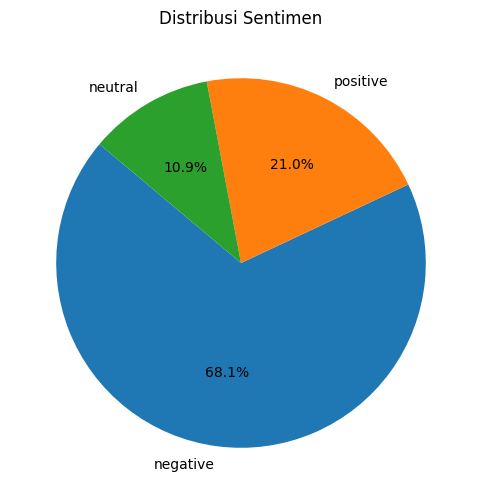

In [ ]:
# Visualisasi Distribusi Sentimen
jumlah_sentimen = df_cleaned['polarity'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(jumlah_sentimen, labels=jumlah_sentimen.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribusi Sentimen')
plt.show()

In [ ]:
# Mengatur opsi tampilan Pandas agar kolom dapat menampilkan teks hingga 5000 karakter.
pd.set_option('display.max_colwidth', 5000)

def function_tweets(df, sentiment):
    filter_tweets = df[df['polarity'] == sentiment][['text_akhir', 'polarity_score', 'polarity', 'text_stopword']]
    filter_tweets = filter_tweets.sort_values(by='polarity_score', ascending=False).reset_index(drop=True)
    filter_tweets.index += 1
    return filter_tweets

# Membuat DataFrame untuk setiap kategori sentimen
positive_tweets = function_tweets(df_cleaned, 'positive')
negative_tweets = function_tweets(df_cleaned, 'negative')
neutral_tweets = function_tweets(df_cleaned, 'neutral')

In [99]:
# Membuat wordcloud berdasarkan polaritas
def create_wordcloud(df, title):
    list = ''
    for tweet in df['text_stopword']:
        for word in tweet:
            list += word + ' '
    
    wordcloud = WordCloud(width=600, height=400, background_color='white', min_font_size=10).generate(list)
    
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_title(title, fontsize=18)
    ax.grid(False)
    ax.imshow(wordcloud)
    ax.axis('off')
    fig.tight_layout(pad=0)
    plt.show()

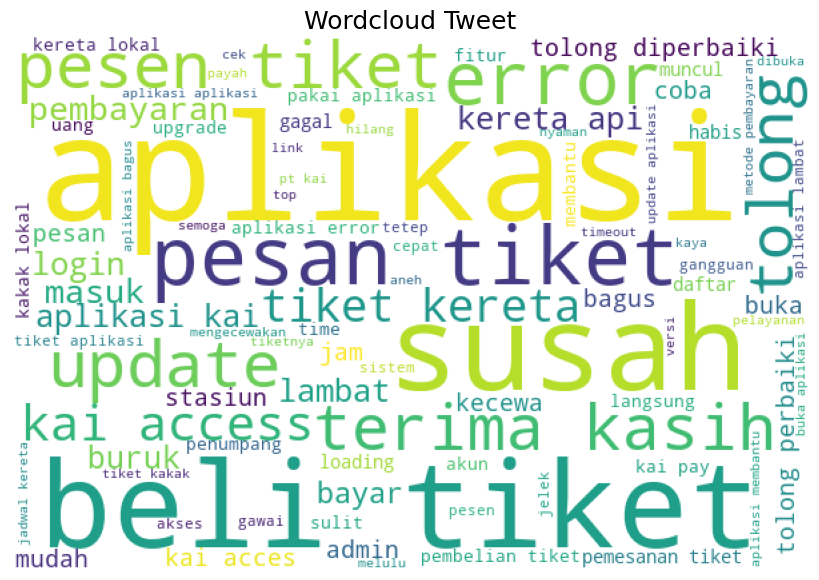

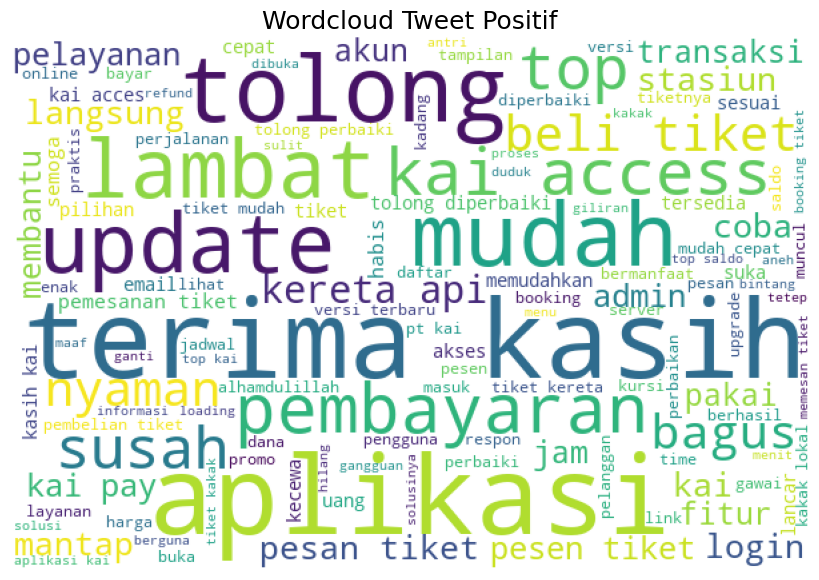

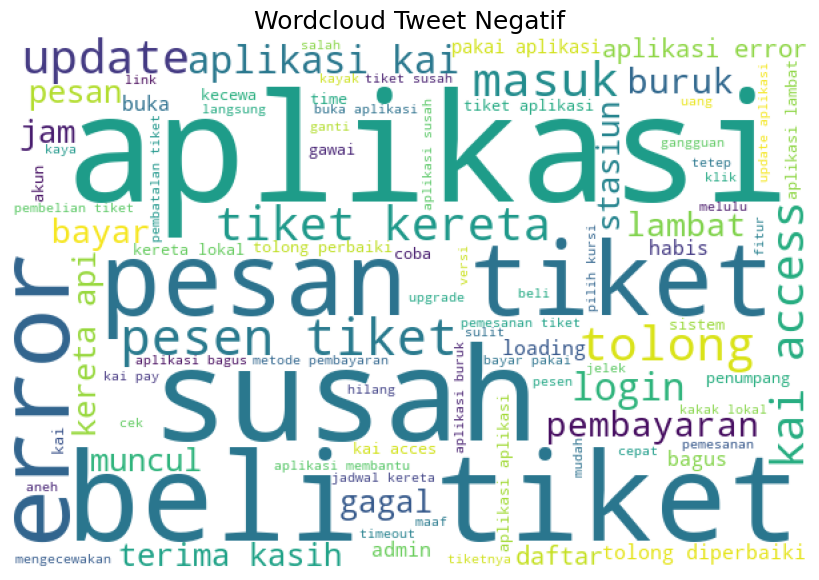

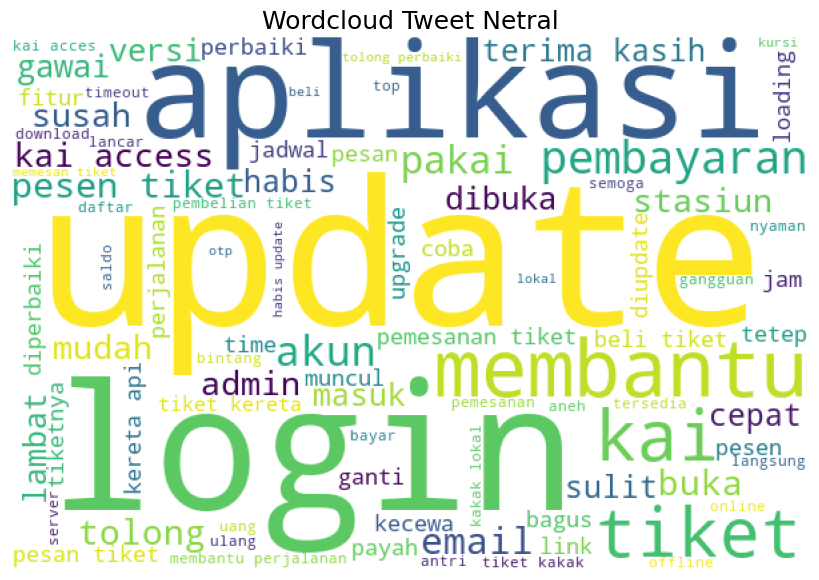

In [100]:
# Membuat wordcloud untuk setiap kategori sentimen
create_wordcloud(df_cleaned, 'Wordcloud Tweet')
create_wordcloud(positive_tweets, 'Wordcloud Tweet Positif')
create_wordcloud(negative_tweets, 'Wordcloud Tweet Negatif')
create_wordcloud(neutral_tweets, 'Wordcloud Tweet Netral')

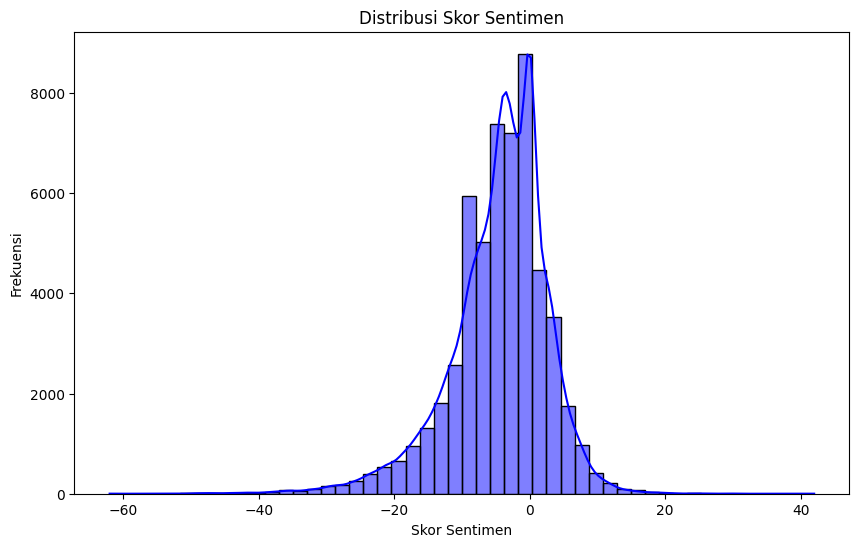

In [101]:
# Menampilkan distribusi skor sentimen dengan histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['polarity_score'], bins=50, color='blue', kde=True)
plt.title('Distribusi Skor Sentimen')
plt.xlabel('Skor Sentimen')
plt.ylabel('Frekuensi')
plt.show()

## **Data Splitting**

In [ ]:
# Pisahkan data menjadi fitur dan label
X = df_cleaned['text_akhir']
labelencoder = LabelEncoder()
y = labelencoder.fit_transform(df_cleaned['polarity'])

In [ ]:
# State early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# State callback
class Callback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get('accuracy') > 0.95:
            print("\nAkurasi lebih dari 95%. Berhenti pelatihan.")
            self.model.stop_training = True
Callback = Callback()

# **Modelling**

- **Model 1**
    - SVC
    - Training 70
    - Testing 30

- **Model 2**
    - LSTM
    - Training 70
    - Testing 30

- **Model 3**
    - GRU
    - Training 80
    - Testing 20


## **Model 1 - SVC (70/30)**

### **Data Splitting**

In [105]:
X_train_SVC, X_test_SVC, y_train_SVC, y_test_SVC = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Ukuran data latih:", X_train_SVC.shape)
print("Ukuran data uji:", X_test_SVC.shape)

Ukuran data latih: (38500,)
Ukuran data uji: (16500,)


### **TF-IDF Tokenizing**

In [106]:
tokenizer_tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))  # 1-2 gram biar konteks dapet
X_train_tfidf = tokenizer_tfidf.fit_transform(X_train_SVC)
X_test_tfidf = tokenizer_tfidf.transform(X_test_SVC)

print("Ukuran matriks TF-IDF (train):", X_train_tfidf.shape)
print("Ukuran matriks TF-IDF (test):", X_test_tfidf.shape)


Ukuran matriks TF-IDF (train): (38500, 5000)
Ukuran matriks TF-IDF (test): (16500, 5000)


### **Modelling**

In [ ]:
model_svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=True,
    random_state=42
)

model_svc.fit(X_train_tfidf, y_train_SVC)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [108]:
y_pred_train_SVC = model_svc.predict(X_train_tfidf)
y_pred_test_SVC = model_svc.predict(X_test_tfidf)

### **Model Evaluation**

In [109]:
# Metrik evaluasi
accuracy_SVC = accuracy_score(y_test_SVC, y_pred_test_SVC)
precision_SVC = precision_score(y_test_SVC, y_pred_test_SVC, average='weighted')
recall_SVC = recall_score(y_test_SVC, y_pred_test_SVC, average='weighted')
f1_SVC = f1_score(y_test_SVC, y_pred_test_SVC, average='weighted')

# Akurasi latih & uji
accuracy_train_SVC = accuracy_score(y_train_SVC, y_pred_train_SVC)
accuracy_test_SVC = accuracy_SVC

print('\n=== Evaluasi Model SVC (Support Vector Classifier) ===')
print('Akurasi  :', accuracy_SVC)
print('Presisi  :', precision_SVC)
print('Recall   :', recall_SVC)
print('F1-Score :', f1_SVC)

print('\n=== Classification Report SVC ===')
print(classification_report(y_test_SVC, y_pred_test_SVC, target_names=['negative', 'neutral', 'positive']))

print('Akurasi pada data latih: %.4f' % (accuracy_train_SVC))
print('Akurasi pada data uji: %.4f' % (accuracy_test_SVC))



=== Evaluasi Model SVC (Support Vector Classifier) ===
Akurasi  : 0.9058181818181819
Presisi  : 0.907857487090261
Recall   : 0.9058181818181819
F1-Score : 0.9066365198765797

=== Classification Report SVC ===
              precision    recall  f1-score   support

    negative       0.96      0.94      0.95     11236
     neutral       0.71      0.72      0.71      1801
    positive       0.84      0.88      0.86      3463

    accuracy                           0.91     16500
   macro avg       0.84      0.85      0.84     16500
weighted avg       0.91      0.91      0.91     16500

Akurasi pada data latih: 0.9864
Akurasi pada data uji: 0.9058


### **Saving SVC Model**

In [110]:
with open('model_svc.pkl', 'wb') as f:
    pickle.dump(model_svc, f)

with open('tfidf_vectorizer.pickle', 'wb') as f:
    pickle.dump(tokenizer_tfidf, f)

## **Model 2 - LSTM (70/30)**

### **Data Splitting**

In [111]:
# Membagi data menjadi set pelatihan dan pengujian
X_train_LSTM, X_test_LSTM, y_train_LSTM, y_test_LSTM = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [112]:
# Mengecek ukuran data pelatihan dan pengujian
print("Ukuran data pelatihan:", X_train_LSTM.shape)
print("Ukuran data pengujian:", X_test_LSTM.shape)

print("Ukuran label pelatihan:", y_train_LSTM.shape)
print("Ukuran label pengujian:", y_test_LSTM.shape)

Ukuran data pelatihan: (38500,)
Ukuran data pengujian: (16500,)
Ukuran label pelatihan: (38500,)
Ukuran label pengujian: (16500,)


### **Data Preprocessing**

In [113]:
# Preprocessing LSTM
max_words = 5000
max_len = 100
tokenizer_LSTM = Tokenizer(num_words=max_words)
tokenizer_LSTM.fit_on_texts(X_train_LSTM)

X_train_LSTM = tokenizer_LSTM.texts_to_sequences(X_train_LSTM)
X_test_LSTM = tokenizer_LSTM.texts_to_sequences(X_test_LSTM)

X_train_LSTM = pad_sequences(X_train_LSTM, maxlen=max_len)
X_test_LSTM = pad_sequences(X_test_LSTM, maxlen=max_len)

# Label ke one-hot encoding
y_train_LSTM = pd.get_dummies(y_train_LSTM).values
y_test_LSTM = pd.get_dummies(y_test_LSTM).values

### **Modelling**

In [114]:
# Membangun model LSTM
model_LSTM = Sequential()
model_LSTM.add(Embedding(max_words, 256, input_length=max_len))
model_LSTM.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01), return_sequences=True))
model_LSTM.add(LSTM(64, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01)))
model_LSTM.add(Dense(128, activation='relu'))
model_LSTM.add(Dense(64, activation='relu'))
model_LSTM.add(Dense(3, activation='softmax'))
model_LSTM.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Melatih dengan early stopping
batch_size = 1028
history_LSTM = model_LSTM.fit(X_train_LSTM, y_train_LSTM, epochs=20, batch_size = batch_size,callbacks=[early_stopping], validation_data=(X_test_LSTM, y_test_LSTM))

Epoch 1/20


c:\Users\Aflah Ghozi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 719ms/step - accuracy: 0.6703 - loss: 3.8513 - val_accuracy: 0.6810 - val_loss: 2.1759
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 696ms/step - accuracy: 0.7250 - loss: 1.4603 - val_accuracy: 0.8042 - val_loss: 0.8958
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 25s 665ms/step - accuracy: 0.8518 - loss: 0.6280 - val_accuracy: 0.8941 - val_loss: 0.4445
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 823ms/step - accuracy: 0.9099 - loss: 0.3537 - val_accuracy: 0.9127 - val_loss: 0.3213
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 33s 878ms/step - accuracy: 0.9384 - loss: 0.2447 - val_accuracy: 0.9357 - val_loss: 0.2525
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 28s 741ms/step - accuracy: 0.9496 - loss: 0.1966 - val_accuracy: 0.9398 - val_loss: 0.2391
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 27s 717ms/step - accuracy: 0.9600 - loss: 0.1629 - val_accuracy: 0.9288 - val_loss: 0.2604
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 808ms/step - accuracy: 0.9638 - loss: 0.1466 - val_accuracy: 0.945

### **Model Evaluation**

In [115]:
# Evaluasi model LSTM
loss_LSTM, accuracy_LSTM = model_LSTM.evaluate(X_test_LSTM, y_test_LSTM, verbose=2)
print(f"Loss: {loss_LSTM:.4f}")
print(f"Akurasi: {accuracy_LSTM:.4f}")

516/516 - 10s - 20ms/step - accuracy: 0.9502 - loss: 0.2096
Loss: 0.2096
Akurasi: 0.9502


In [116]:
# Classification report LSTM
y_pred_prob_LSTM = model_LSTM.predict(X_test_LSTM)
y_pred_LSTM = np.argmax(y_pred_prob_LSTM, axis=1)
y_test_LSTM = np.argmax(y_test_LSTM, axis=1)

accuracy_LSTM = accuracy_score(y_test_LSTM, y_pred_LSTM)
precision_LSTM = precision_score(y_test_LSTM, y_pred_LSTM, average='weighted')
recall_LSTM = recall_score(y_test_LSTM, y_pred_LSTM, average='weighted')
f1_LSTM = f1_score(y_test_LSTM, y_pred_LSTM, average='weighted')

print('\n=== Evaluasi Model LSTM ===')
print('Akurasi:', accuracy_LSTM)
print('Presisi:', precision_LSTM)
print('Recall:', recall_LSTM)
print('F1-Score:', f1_LSTM)

print('\n=== Classification Report LSTM ===')
print(classification_report(y_test_LSTM, y_pred_LSTM, target_names=['negative', 'neutral', 'positive']))

print('Akurasi pada data latih: %.4f' % (history_LSTM.history['accuracy'][-1]))
print('Akurasi pada data uji: %.4f' % (accuracy_LSTM))

516/516 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step

=== Evaluasi Model LSTM ===
Akurasi: 0.9501818181818181
Presisi: 0.9509544291142235
Recall: 0.9501818181818181
F1-Score: 0.950505386590724

=== Classification Report LSTM ===
              precision    recall  f1-score   support

    negative       0.98      0.98      0.98     11236
     neutral       0.80      0.83      0.82      1801
    positive       0.94      0.93      0.93      3463

    accuracy                           0.95     16500
   macro avg       0.91      0.91      0.91     16500
weighted avg       0.95      0.95      0.95     16500

Akurasi pada data latih: 0.9811
Akurasi pada data uji: 0.9502


### **Saving LSTM Model**

In [117]:
model_LSTM.save('model_lstm.h5')

with open('tokenizer_LSTM.pickle', 'wb') as f:
    pickle.dump(tokenizer_LSTM, f)

## **Model 3 - GRU 80/20**

### **Data Splitting**

In [118]:
X_train_GRU, X_test_GRU, y_train_GRU, y_test_GRU = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

In [119]:
# Mengecek ukuran data pelatihan dan pengujian
print("Ukuran data pelatihan:", X_train_GRU.shape)
print("Ukuran data pengujian:", X_test_GRU.shape)

print("Ukuran label pelatihan:", y_train_GRU.shape)
print("Ukuran label pengujian:", y_test_GRU.shape)

Ukuran data pelatihan: (44000,)
Ukuran data pengujian: (11000,)
Ukuran label pelatihan: (44000,)
Ukuran label pengujian: (11000,)


### **Data Preprocessing**

In [120]:
max_words = 5000
max_len = 100
tokenizer_GRU = Tokenizer(num_words=max_words)
tokenizer_GRU.fit_on_texts(X_train_GRU)

X_train_GRU = tokenizer_GRU.texts_to_sequences(X_train_GRU)
X_test_GRU = tokenizer_GRU.texts_to_sequences(X_test_GRU)

X_train_GRU = pad_sequences(X_train_GRU, maxlen=max_len)
X_test_GRU = pad_sequences(X_test_GRU, maxlen=max_len)

# Label ke one-hot encoding
y_train_GRU = pd.get_dummies(y_train_GRU).values
y_test_GRU = pd.get_dummies(y_test_GRU).values

### **Modelling**

In [121]:
model_GRU = Sequential()
model_GRU.add(Embedding(max_words, 256, input_length=max_len))
model_GRU.add(GRU(128, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01), return_sequences=True))
model_GRU.add(GRU(64, dropout=0.2, recurrent_dropout=0.2, kernel_regularizer=l2(0.01)))
model_GRU.add(Dense(128, activation='relu'))
model_GRU.add(Dense(64, activation='relu'))
model_GRU.add(Dense(3, activation='softmax'))
model_GRU.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Melatih dengan early stopping
batch_size = 1028
history_GRU = model_GRU.fit(X_train_GRU, y_train_GRU, epochs=20, batch_size = batch_size,callbacks=[early_stopping], validation_data=(X_test_GRU, y_test_GRU))

Epoch 1/20


c:\Users\Aflah Ghozi\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


43/43 ━━━━━━━━━━━━━━━━━━━━ 35s 723ms/step - accuracy: 0.7098 - loss: 3.3739 - val_accuracy: 0.7940 - val_loss: 1.7558
Epoch 2/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 30s 709ms/step - accuracy: 0.8498 - loss: 1.0602 - val_accuracy: 0.9060 - val_loss: 0.6011
Epoch 3/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 676ms/step - accuracy: 0.9209 - loss: 0.4125 - val_accuracy: 0.9135 - val_loss: 0.3402
Epoch 4/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 33s 776ms/step - accuracy: 0.9467 - loss: 0.2288 - val_accuracy: 0.9379 - val_loss: 0.2349
Epoch 5/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 32s 748ms/step - accuracy: 0.9571 - loss: 0.1683 - val_accuracy: 0.9395 - val_loss: 0.2109
Epoch 6/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 37s 667ms/step - accuracy: 0.9636 - loss: 0.1405 - val_accuracy: 0.9429 - val_loss: 0.1995
Epoch 7/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 29s 676ms/step - accuracy: 0.9661 - loss: 0.1280 - val_accuracy: 0.9443 - val_loss: 0.1986
Epoch 8/20
43/43 ━━━━━━━━━━━━━━━━━━━━ 28s 647ms/step - accuracy: 0.9685 - loss: 0.1186 - val_accuracy: 0.947

### **Model Evaluation**

In [122]:
# Evaluasi model GRU
loss_GRU, accuracy_GRU = model_GRU.evaluate(X_test_GRU, y_test_GRU, verbose=2)
print(f"Loss: {loss_GRU:.4f}")
print(f"Akurasi: {accuracy_GRU:.4f}")

344/344 - 7s - 21ms/step - accuracy: 0.9496 - loss: 0.1847
Loss: 0.1847
Akurasi: 0.9496


In [123]:
# Classification report GRU
y_pred_prob_GRU = model_GRU.predict(X_test_GRU)
y_pred_GRU = np.argmax(y_pred_prob_GRU, axis=1)
y_test_GRU = np.argmax(y_test_GRU, axis=1)

accuracy_GRU = accuracy_score(y_test_GRU, y_pred_GRU)
precision_GRU = precision_score(y_test_GRU, y_pred_GRU, average='weighted')
recall_GRU = recall_score(y_test_GRU, y_pred_GRU, average='weighted')
f1_GRU = f1_score(y_test_GRU, y_pred_GRU, average='weighted')

print('Evaluasi Model GRU')
print('Akurasi:', accuracy_GRU)
print('Presisi:', precision_GRU)
print('Recall:', recall_GRU)
print('F1-Score:', f1_GRU)

print('Classification Report GRU')
print(classification_report(y_test_GRU, y_pred_GRU, target_names=['negative', 'neutral', 'positive']))
print('Akurasi pada data latih: %.4f' % (history_GRU.history['accuracy'][-1]))
print('Akurasi pada data uji: %.4f' % (accuracy_GRU))

344/344 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step
Evaluasi Model GRU
Akurasi: 0.9496363636363636
Presisi: 0.9491966408163925
Recall: 0.9496363636363636
F1-Score: 0.9493441711243408
Classification Report GRU
              precision    recall  f1-score   support

    negative       0.98      0.98      0.98      7490
     neutral       0.83      0.80      0.82      1201
    positive       0.92      0.94      0.93      2309

    accuracy                           0.95     11000
   macro avg       0.91      0.91      0.91     11000
weighted avg       0.95      0.95      0.95     11000

Akurasi pada data latih: 0.9821
Akurasi pada data uji: 0.9496


### **Saving GRU Model**

In [124]:
model_GRU.save('model_gru.h5')

with open('tokenizer_GRU.pickle', 'wb') as f:
    pickle.dump(tokenizer_GRU, f)

### **Overall Model Accuracy**

In [125]:
summary_df = pd.DataFrame({
    'Model': ['SVC', 'LSTM', 'GRU'],
    'Akurasi Data Latih': [accuracy_train_SVC, history_LSTM.history['accuracy'][-1], history_GRU.history['accuracy'][-1]],
    'Akurasi Data Uji': [accuracy_SVC, accuracy_LSTM, accuracy_GRU]
})
summary_df = summary_df.sort_values(by='Akurasi Data Uji', ascending=False).reset_index(drop=True)
summary_df

,Model,Akurasi Data Latih,Akurasi Data Uji
0,LSTM,0.981091,0.950182
1,GRU,0.982091,0.949636
2,SVC,0.986390,0.905818


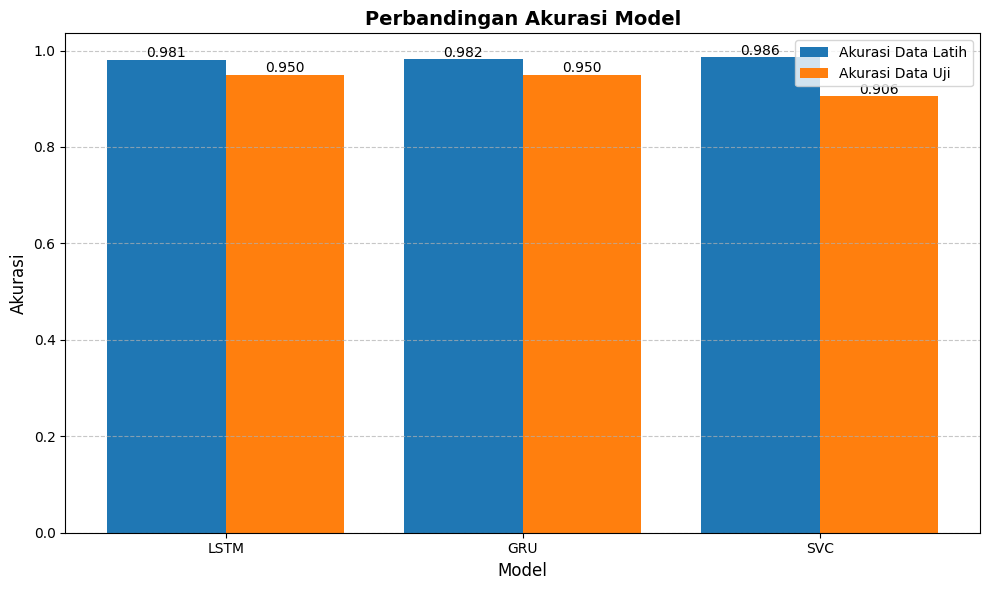

In [126]:
plt.figure(figsize=(10, 6))

models = summary_df['Model']
train_acc = summary_df['Akurasi Data Latih']
test_acc = summary_df['Akurasi Data Uji']

x = np.arange(len(models))
bar_width = 0.4

plt.bar(x - bar_width/2, train_acc, width=bar_width, label='Akurasi Data Latih')
plt.bar(x + bar_width/2, test_acc, width=bar_width, label='Akurasi Data Uji')

plt.xticks(x, models)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Akurasi', fontsize=12)
plt.title('Perbandingan Akurasi Model', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

for i, v in enumerate(train_acc):
    plt.text(x[i] - bar_width/2, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)
for i, v in enumerate(test_acc):
    plt.text(x[i] + bar_width/2, v + 0.005, f"{v:.3f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


## **Testing New Data**

In [127]:
# Data baru dan label aslinya
new_data = [
    'Pembayaran lama dan berakhir gagal.',
    'Pemesanan tiket mudah dan cepat.',
    'Basic saja ngga ada yang istimewa.',
]
label_new_data = ['negative', 'positive', 'neutral']

# Fungsi prediksi untuk model Keras (LSTM & GRU)
def predict_texts_deep(texts, tokenizer, model, labelencoder, max_len):
    sequences = tokenizer.texts_to_sequences(texts)
    padded = pad_sequences(sequences, maxlen=max_len)
    probs = model.predict(padded)
    predicted_labels = labelencoder.inverse_transform(np.argmax(probs, axis=1))
    return predicted_labels, probs

# Fungsi prediksi untuk model SVC
def predict_texts_svc(texts, vectorizer, model, labelencoder):
    X_new = vectorizer.transform(texts)
    probs = model.predict_proba(X_new)
    predicted_labels = labelencoder.inverse_transform(np.argmax(probs, axis=1))
    return predicted_labels, probs

# Prediksi dari masing-masing model
labels_SVC, probs_SVC = predict_texts_svc(new_data, tokenizer_tfidf, model_svc, labelencoder)
labels_LSTM, probs_LSTM = predict_texts_deep(new_data, tokenizer_LSTM, model_LSTM, labelencoder, max_len)
labels_GRU, probs_GRU = predict_texts_deep(new_data, tokenizer_GRU, model_GRU, labelencoder, max_len)

# Tampilkan hasil prediksi
for i, text in enumerate(new_data):
    print(f"\nTeks: {text}")
    print(f"Label Asli   : {label_new_data[i]}")
    print(f"Prediksi SVC  : {labels_SVC[i]} | Prob: {probs_SVC[i]}")
    print(f"Prediksi LSTM : {labels_LSTM[i]} | Prob: {probs_LSTM[i]}")
    print(f"Prediksi GRU  : {labels_GRU[i]} | Prob: {probs_GRU[i]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Teks: Pembayaran lama dan berakhir gagal.
Label Asli   : negative
Prediksi SVC  : negative | Prob: [9.99953962e-01 4.59657892e-05 7.24798494e-08]
Prediksi LSTM : negative | Prob: [9.9998975e-01 1.0272807e-05 3.5021628e-08]
Prediksi GRU  : negative | Prob: [9.9999845e-01 1.5965226e-06 6.4338295e-09]

Teks: Pemesanan tiket mudah dan cepat.
Label Asli   : positive
Prediksi SVC  : positive | Prob: [5.16465585e-04 3.01240834e-02 9.69359451e-01]
Prediksi LSTM : positive | Prob: [4.9341638e-06 4.8047852e-05 9.9994707e-01]
Prediksi GRU  : positive | Prob: [2.8465885e-05 3.2787808e-04 9.9964368e-01]

Teks: Basic saja ngga ada yang istimewa.
Label Asli   : neutral
Prediksi SVC  : neutral | Prob: [0.03735738 0.92587095 0.03677167]
Prediksi LSTM : neutral | Prob: [0.00968316 0.9870156  0.00330121]
Prediksi GRU  : neutral | Prob: [0.0059254  0.9906104  0.00346419]
